# Классификация отзывов WB по корневым категориям
**Модель:** `DeepPavlov/rubert-base-cased-sentence`  
**Методы:** Логистическая регрессия · Центроидный классификатор · Сиамская сеть (метрическое обучение)

## 0. Установка зависимостей

In [ ]:
!pip install -q sentence-transformers scikit-learn sqlalchemy psycopg2-binary pandas numpy matplotlib seaborn torch h5py tqdm

## 1. Импорты и глобальные настройки

In [1]:
import numpy as np
import pandas as pd
import random
import os
import h5py
import warnings
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset

from sqlalchemy import create_engine
from sentence_transformers import SentenceTransformer

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import f1_score, confusion_matrix

import matplotlib.pyplot as plt
import seaborn as sns

# ── Воспроизводимость ──────────────────────────────────────────────────────────
SEED = 42

def set_seed(seed: int = SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)

set_seed(SEED)
print(f"SEED = {SEED}  |  torch {torch.__version__}  |  CUDA: {torch.cuda.is_available()}")

SEED = 42  |  torch 2.10.0+cpu  |  CUDA: False


## 2. Подключение к PostgreSQL

In [2]:
DB_USER     = 'admin'
DB_PASSWORD = 'admin123'
DB_HOST     = 'localhost'
DB_PORT     = '5433'
DB_NAME     = 'wb_reviews'

engine = create_engine(f'postgresql://{DB_USER}:{DB_PASSWORD}@{DB_HOST}:{DB_PORT}/{DB_NAME}')
print("Подключение к БД установлено.")

Подключение к БД установлено.


## 3. Загрузка эмбеддинг-модели

In [3]:
MODEL_NAME = 'DeepPavlov/rubert-base-cased-sentence'
print(f"Загрузка модели {MODEL_NAME} ...")
model_st = SentenceTransformer(MODEL_NAME)
print("Модель загружена.")

Загрузка модели DeepPavlov/rubert-base-cased-sentence ...


No sentence-transformers model found with name DeepPavlov/rubert-base-cased-sentence. Creating a new one with mean pooling.


config.json:   0%|          | 0.00/642 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/711M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/711M [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/24.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

Модель загружена.


## 4. Параметры загрузки данных

In [4]:
CHUNK_SIZE  = 10_000   # размер чанка при чтении из БД
TOTAL_LIMIT = 30_000   # максимальное число строк, считываемых из БД

## 5. Загрузка данных из БД и векторизация

In [5]:
sql_query = f"""
SELECT
    r.review_text,
    p.subj_root_name
FROM wb_reviews r
INNER JOIN wb_products p ON r.nm_id = p.nm_id
WHERE r.review_text IS NOT NULL
  AND r.review_text <> ''
GROUP BY r.id, p.subj_root_name
LIMIT {TOTAL_LIMIT}
"""

X_vectors, y_root, raw_texts_all = [], [], []

print("Чтение данных из БД и векторизация...")
for chunk in pd.read_sql(sql_query, engine, chunksize=CHUNK_SIZE):
    texts = chunk['review_text'].tolist()
    embeddings = model_st.encode(texts, batch_size=32, show_progress_bar=False)
    X_vectors.extend(embeddings.astype(np.float32))
    y_root.extend(chunk['subj_root_name'].tolist())
    raw_texts_all.extend(texts)

X_all        = np.array(X_vectors, dtype=np.float32)
y_all        = np.array(y_root)
texts_all    = np.array(raw_texts_all)
print(f"Векторизация завершена. Загружено записей: {len(X_all)}")

Чтение данных из БД и векторизация...
Векторизация завершена. Загружено записей: 30000


## 6. Сводка категорий и выбор рабочего набора

In [6]:
cat_counts = pd.Series(y_all).value_counts().reset_index()
cat_counts.columns = ['Категория', 'Количество отзывов']
print("=" * 55)
print("СВОДКА: корневые категории в датасете")
print("=" * 55)
print(cat_counts.to_string(index=False))
print("=" * 55)
print(f"Итого категорий: {len(cat_counts)}  |  Всего отзывов: {len(y_all)}")

СВОДКА: корневые категории в датасете
                     Категория  Количество отзывов
                        Одежда               10704
                         Обувь                5957
                         Белье                2243
                       Красота                2163
                    Аксессуары                1162
            Товары для малышей                 921
               Бытовая техника                 650
                           Дом                 642
           Ювелирные украшения                 600
                       Игрушки                 545
             Спортивная одежда                 540
            Одежда для малышей                 410
     Книжная продукция и диски                 297
        Смартфоны и аксессуары                 292
            Посуда и инвентарь                 283
                Головные уборы                 255
             Техника для кухни                 237
              Спортивный товар              

In [7]:
# ── Выбор категорий ───────────────────────────────────────────────────────────
# ВАРИАНТ A: укажите категории вручную через запятую (оставьте пустым для Варианта Б)
MANUAL_CATEGORIES = "Обувь, Белье, Красота, Аксессуары"   # пример: "Одежда, Обувь, Электроника"

# ВАРИАНТ Б: минимальное число отзывов для автоматического включения категории
MIN_REVIEWS = 500

# ── Применение выбора ─────────────────────────────────────────────────────────
if MANUAL_CATEGORIES.strip():
    selected = [c.strip() for c in MANUAL_CATEGORIES.split(',')]
    missing = [c for c in selected if c not in cat_counts['Категория'].values]
    if missing:
        print(f"   Не найдены в данных: {missing}")
    selected = [c for c in selected if c in cat_counts['Категория'].values]
    print(f"\nВариант А — выбрано вручную ({len(selected)} кат.): {selected}")
else:
    auto_df = cat_counts[cat_counts['Количество отзывов'] >= MIN_REVIEWS]
    selected = auto_df['Категория'].tolist()
    print(f"\nВариант Б — категории с >= {MIN_REVIEWS} отзывов ({len(selected)} шт.):")
    print(auto_df.to_string(index=False))

if not selected:
    raise ValueError("Нет подходящих категорий — измените параметры выбора.")

mask         = np.isin(y_all, selected)
X_filtered   = X_all[mask]
y_filtered   = y_all[mask]
texts_filtered = texts_all[mask]
print(f"\nПосле фильтрации: {len(X_filtered)} отзывов, {len(np.unique(y_filtered))} категорий.")


Вариант А — выбрано вручную (4 кат.): ['Обувь', 'Белье', 'Красота', 'Аксессуары']

После фильтрации: 11525 отзывов, 4 категорий.


## 7. Балансировка классов

In [8]:
MAX_PER_CLASS  = 2000
MIN_PER_CLASS  = 100
IMBALANCE_RATIO = 5.0

set_seed(SEED)
df_bal = pd.DataFrame({'text_idx': range(len(X_filtered)),
                       'root': y_filtered})

counts_before = df_bal['root'].value_counts()
ratio = counts_before.max() / counts_before.min()

if ratio > IMBALANCE_RATIO:
    print(f"   Дисбаланс классов обнаружен (max/min = {ratio:.1f}):")
    print(counts_before.to_string())
else:
    print(f"Дисбаланс в норме (max/min = {ratio:.1f}).")

# Шаг 1: догрузка малых классов из БД
small_classes = counts_before[counts_before < MIN_PER_CLASS * 2].index.tolist()
enlarged_classes = []
if small_classes:
    print(f"\nДогрузка данных для малых классов: {small_classes}")
    placeholders = ', '.join([f"'{c}'" for c in small_classes])
    extra_sql = f"""
        SELECT r.review_text, p.subj_root_name
        FROM wb_reviews r
        INNER JOIN wb_products p ON r.nm_id = p.nm_id
        WHERE p.subj_root_name IN ({placeholders})
          AND r.review_text IS NOT NULL AND r.review_text <> ''
        GROUP BY r.id, p.subj_root_name
    """
    try:
        extra_df = pd.read_sql(extra_sql, engine)
        if len(extra_df) > 0:
            extra_emb = model_st.encode(extra_df['review_text'].tolist(),
                                        batch_size=32, show_progress_bar=False).astype(np.float32)
            X_filtered     = np.vstack([X_filtered, extra_emb])
            y_extra        = extra_df['subj_root_name'].values
            y_filtered     = np.concatenate([y_filtered, y_extra])
            texts_filtered = np.concatenate([texts_filtered, extra_df['review_text'].values])
            df_bal = pd.DataFrame({'text_idx': range(len(X_filtered)), 'root': y_filtered})
            enlarged_classes = small_classes
            print(f"  Увеличен размер классов: {enlarged_classes}")
    except Exception as e:
        print(f"Не удалось догрузить данные: {e}")

# Шаг 2: исключение слишком малых классов
counts_now = df_bal['root'].value_counts()
too_small  = counts_now[counts_now < MIN_PER_CLASS].index.tolist()
removed_classes = []
if too_small:
    df_bal = df_bal[~df_bal['root'].isin(too_small)]
    removed_classes = too_small
    print(f"  Удалены категории (< {MIN_PER_CLASS} отзывов): {removed_classes}")

# Шаг 3: обрезка слишком больших классов
balanced_indices = []
for cat, grp in df_bal.groupby('root'):
    idx = grp['text_idx'].values
    if len(idx) > MAX_PER_CLASS:
        idx = np.random.choice(idx, MAX_PER_CLASS, replace=False)
    balanced_indices.extend(idx)

balanced_indices = np.array(balanced_indices)
X_bal     = X_filtered[balanced_indices]
y_bal     = y_filtered[balanced_indices]
texts_bal = texts_filtered[balanced_indices]

final_counts = pd.Series(y_bal).value_counts()
print("\nРаспределение классов после балансировки:")
print(final_counts.to_string())
print(f"\nИтого: {len(X_bal)} отзывов, {len(final_counts)} категорий.")
if removed_classes:  print(f"Удалены категории: {removed_classes}")
if enlarged_classes: print(f"Увеличен размер классов: {enlarged_classes}")

   Дисбаланс классов обнаружен (max/min = 5.1):
root
Обувь         5957
Белье         2243
Красота       2163
Аксессуары    1162

Распределение классов после балансировки:
Белье         2000
Красота       2000
Обувь         2000
Аксессуары    1162

Итого: 7162 отзывов, 4 категорий.


## 8. Разбивка на train / val / test и кодирование меток

In [9]:
set_seed(SEED)

X_train, X_temp, y_train, y_temp, texts_train, texts_temp = train_test_split(
    X_bal, y_bal, texts_bal,
    test_size=0.30, random_state=SEED, stratify=y_bal
)
X_val, X_test, y_val, y_test, texts_val, texts_test = train_test_split(
    X_temp, y_temp, texts_temp,
    test_size=0.50, random_state=SEED, stratify=y_temp
)

# ── Гарантия: нет unseen-категорий в val/test ─────────────────────────────────
train_cats  = set(y_train)
unseen_val  = set(y_val)  - train_cats
unseen_test = set(y_test) - train_cats

if unseen_val or unseen_test:
    print(f"   Unseen в val: {unseen_val} | в test: {unseen_test} — удаляем.")
    m_val   = np.isin(y_val,  list(train_cats))
    X_val, y_val, texts_val   = X_val[m_val],  y_val[m_val],  texts_val[m_val]
    m_test  = np.isin(y_test, list(train_cats))
    X_test, y_test, texts_test = X_test[m_test], y_test[m_test], texts_test[m_test]
    assert len(X_val) > 0 and len(X_test) > 0
else:
    print("   Все категории в val/test присутствуют в train.")

le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)
y_val_enc   = le.transform(y_val)
y_test_enc  = le.transform(y_test)

CLASS_NAMES = le.classes_.tolist()
print(f"\nTrain: {len(X_train)}  |  Val: {len(X_val)}  |  Test: {len(X_test)}")
print(f"Классы ({len(CLASS_NAMES)}): {CLASS_NAMES}")

   Все категории в val/test присутствуют в train.

Train: 5013  |  Val: 1074  |  Test: 1075
Классы (4): ['Аксессуары', 'Белье', 'Красота', 'Обувь']


## 9. Сохранение выборок в HDF5

In [11]:
def save_split_hdf5(path, X, y_enc, y_str, texts, class_names):
    with h5py.File(path, 'w') as f:
        f.create_dataset('X', data=X, compression='gzip')
        f.create_dataset('y_enc', data=y_enc)
        dt = h5py.string_dtype(encoding='utf-8')
        # Преобразуем строковые данные в object-массив для корректного сохранения
        f.create_dataset('y_str', data=np.asarray(y_str, dtype=object), dtype=dt)
        f.create_dataset('texts', data=np.asarray(texts, dtype=object), dtype=dt)
        f.create_dataset('classes', data=np.asarray(class_names, dtype=object), dtype=dt)
    print(f"  Сохранено: {path}  ({len(X)} записей)")

print("Сохранение выборок...")
save_split_hdf5('train_split_rubert.h5', X_train, y_train_enc, y_train, texts_train, CLASS_NAMES)
save_split_hdf5('val_split_rubert.h5',   X_val,   y_val_enc,   y_val,   texts_val,   CLASS_NAMES)
save_split_hdf5('test_split_rubert.h5',  X_test,  y_test_enc,  y_test,  texts_test,  CLASS_NAMES)

Сохранение выборок...
  Сохранено: train_split_rubert.h5  (5013 записей)
  Сохранено: val_split_rubert.h5  (1074 записей)
  Сохранено: test_split_rubert.h5  (1075 записей)


## 10. Вспомогательные функции визуализации

In [12]:
def plot_confusion_matrix(y_true, y_pred, class_names, title="Confusion Matrix"):
    """Confusion matrix с seaborn heatmap."""
    cm = confusion_matrix(y_true, y_pred)
    fig, ax = plt.subplots(figsize=(max(8, len(class_names)), max(6, len(class_names) - 1)))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names, ax=ax)
    ax.set_xlabel('Предсказано', fontsize=12)
    ax.set_ylabel('Истинное',    fontsize=12)
    ax.set_title(title, fontsize=14)
    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()


def show_random_predictions(y_true_str, y_pred_enc, le, raw_texts, n=10):
    """Вывод N случайных примеров:
    Текст отзыва | Истинная кат. | Предсказание | ✓?
    """
    set_seed(SEED)
    idx = np.random.choice(len(y_true_str), min(n, len(y_true_str)), replace=False)
    y_pred_str = le.inverse_transform(y_pred_enc)

    TEXT_W = 45
    CAT_W  = 28

    header = (f"{'#':<3} "
              f"{'Текст отзыва':<{TEXT_W}} "
              f"{'Истинная кат.':<{CAT_W}} "
              f"{'Предсказание':<{CAT_W}} "
              f"{'✓?'}")
    print(header)
    print("-" * (3 + 1 + TEXT_W + 1 + CAT_W + 1 + CAT_W + 1 + 3))

    for i, pos in enumerate(idx):
        snippet  = str(raw_texts[pos])[:TEXT_W].replace('\n', ' ')
        if len(str(raw_texts[pos])) > TEXT_W:
            snippet = snippet[:-1] + '…'
        true_lbl = y_true_str[pos]
        pred_lbl = y_pred_str[pos]
        ok       = "yes" if true_lbl == pred_lbl else "no"
        print(f"{i+1:<3} "
              f"{snippet:<{TEXT_W}} "
              f"{true_lbl:<{CAT_W}} "
              f"{pred_lbl:<{CAT_W}} "
              f"{ok}")


def evaluate_f1(y_true_enc, y_pred_enc, average='weighted'):
    return f1_score(y_true_enc, y_pred_enc, average=average)


print("Вспомогательные функции определены.")

Вспомогательные функции определены.


---
## Метод А: Логистическая регрессия
Эмбеддинги отзывов → признаки; LR учится разделять классы в этом пространстве.

In [13]:
set_seed(SEED)

print("[A] Обучение логистической регрессии...")
clf_lr = LogisticRegression(max_iter=1000, solver='lbfgs', random_state=SEED)
clf_lr.fit(X_train, y_train_enc)

lr_val_pred  = clf_lr.predict(X_val)
lr_test_pred = clf_lr.predict(X_test)

lr_f1_val  = evaluate_f1(y_val_enc,  lr_val_pred)
lr_f1_test = evaluate_f1(y_test_enc, lr_test_pred)

print(f"F1 (weighted) на val:  {lr_f1_val:.4f}")
print(f"F1 (weighted) на test: {lr_f1_test:.4f}")

[A] Обучение логистической регрессии...
F1 (weighted) на val:  0.8661
F1 (weighted) на test: 0.8631


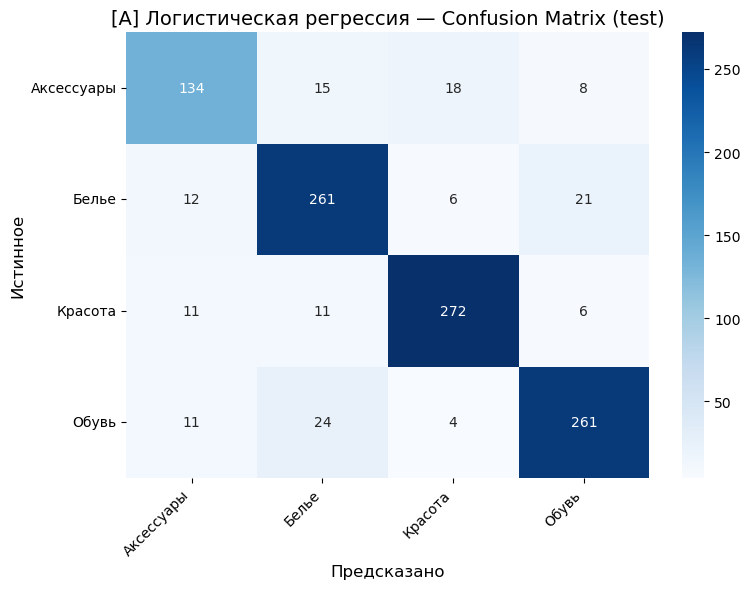

In [14]:
plot_confusion_matrix(y_test_enc, lr_test_pred, CLASS_NAMES,
                      title="[A] Логистическая регрессия — Confusion Matrix (test)")

In [15]:
print("\n[A] 10 случайных примеров предсказаний (тест):")
show_random_predictions(y_test, lr_test_pred, le, texts_test, n=10)


[A] 10 случайных примеров предсказаний (тест):
#   Текст отзыва                                  Истинная кат.                Предсказание                 ✓?
---------------------------------------------------------------------------------------------------------------
1   Спинка у бюстгальтера  понравилась и на этом… Белье                        Белье                        yes
2   Кожа. Смотрится симпатично. После кроксов ре… Обувь                        Аксессуары                   no
3   Шарф , не снуд , вискоза , приятный на ощупь… Аксессуары                   Аксессуары                   yes
4   Как и писали ниже, ее нужно смывать) иначе л… Красота                      Красота                      yes
5   Хорошие сандали, цвет соответствует фото, не… Обувь                        Обувь                        yes
6   Отвратительно, приехал, назвал фамилию, выне… Белье                        Аксессуары                   no
7   На мой 48 размер (ОГ - 102, обхват под грудь… Белье    

### Диалоговое окно — Метод А

In [16]:
dialog_log_lr = []

print("=" * 60)
print("[A] Диалог: классификация текста (LogReg)")
print("Введите 'стоп' для выхода.")
print(f"Доступные категории: {CLASS_NAMES}")
print("=" * 60)

while True:
    user_input = input("Текст отзыва: ").strip()
    if user_input.lower() in ('стоп', 'stop', 'quit', 'exit', ''):
        break
    emb = model_st.encode([user_input])
    pred_enc = clf_lr.predict(emb)[0]
    pred_lbl = le.inverse_transform([pred_enc])[0]
    prob = clf_lr.predict_proba(emb)[0].max()
    print(f"  → Категория: {pred_lbl}  (уверенность: {prob:.2%})\n")
    dialog_log_lr.append({'text': user_input, 'predicted': pred_lbl, 'prob': float(prob)})

if dialog_log_lr:
    with h5py.File('dialog_logreg_rubert.h5', 'w') as f:
        dt = h5py.string_dtype(encoding='utf-8')
        f.create_dataset('texts',       data=np.array([d['text']      for d in dialog_log_lr], dtype='U'), dtype=dt)
        f.create_dataset('predictions', data=np.array([d['predicted'] for d in dialog_log_lr], dtype='U'), dtype=dt)
        f.create_dataset('probs',       data=np.array([d['prob']      for d in dialog_log_lr]))
    print(f"Диалог сохранён: dialog_logreg_rubert.h5  ({len(dialog_log_lr)} запросов)")

[A] Диалог: классификация текста (LogReg)
Введите 'стоп' для выхода.
Доступные категории: ['Аксессуары', 'Белье', 'Красота', 'Обувь']


Текст отзыва:  \


  → Категория: Белье  (уверенность: 99.72%)



Текст отзыва:  exit


TypeError: No conversion path for dtype: dtype('<U1')

---
## Метод Б: Центроидный классификатор
Каждая категория → усреднённый эталонный вектор. Новый отзыв → ближайший центроид (cosine).

In [17]:
from sklearn.metrics.pairwise import cosine_similarity

centroids = {}
for cls_int in np.unique(y_train_enc):
    mask = y_train_enc == cls_int
    centroids[cls_int] = X_train[mask].mean(axis=0)

centroid_matrix = np.array([centroids[i] for i in sorted(centroids)], dtype=np.float32)
print(f"[Б] Центроиды вычислены: {centroid_matrix.shape}  (классов × dim)")

def centroid_predict(X, centroid_matrix):
    sims = cosine_similarity(X, centroid_matrix)
    return np.argmax(sims, axis=1)

cent_val_pred  = centroid_predict(X_val,  centroid_matrix)
cent_test_pred = centroid_predict(X_test, centroid_matrix)

cent_f1_val  = evaluate_f1(y_val_enc,  cent_val_pred)
cent_f1_test = evaluate_f1(y_test_enc, cent_test_pred)

print(f"F1 (weighted) на val:  {cent_f1_val:.4f}")
print(f"F1 (weighted) на test: {cent_f1_test:.4f}")

[Б] Центроиды вычислены: (4, 768)  (классов × dim)
F1 (weighted) на val:  0.6774
F1 (weighted) на test: 0.6760


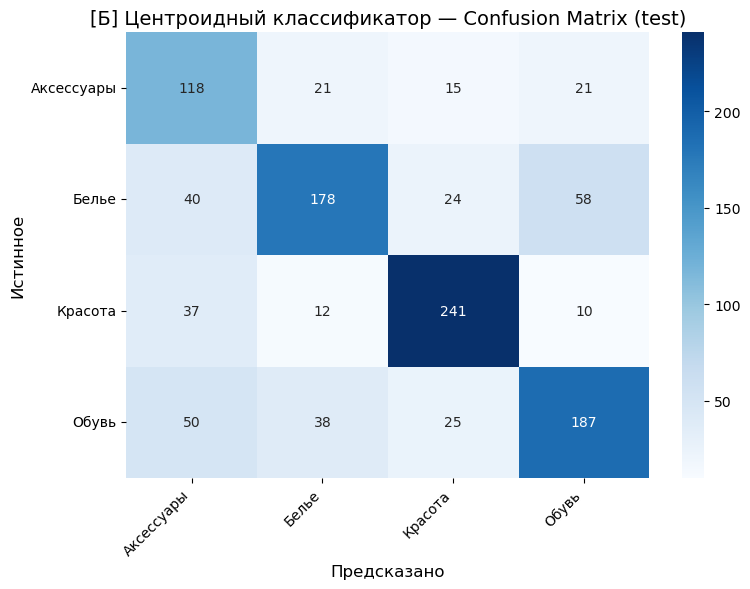

In [18]:
plot_confusion_matrix(y_test_enc, cent_test_pred, CLASS_NAMES,
                      title="[Б] Центроидный классификатор — Confusion Matrix (test)")

In [19]:
print("\n[Б] 10 случайных примеров предсказаний (тест):")
show_random_predictions(y_test, cent_test_pred, le, texts_test, n=10)


[Б] 10 случайных примеров предсказаний (тест):
#   Текст отзыва                                  Истинная кат.                Предсказание                 ✓?
---------------------------------------------------------------------------------------------------------------
1   Спинка у бюстгальтера  понравилась и на этом… Белье                        Белье                        yes
2   Кожа. Смотрится симпатично. После кроксов ре… Обувь                        Белье                        no
3   Шарф , не снуд , вискоза , приятный на ощупь… Аксессуары                   Красота                      no
4   Как и писали ниже, ее нужно смывать) иначе л… Красота                      Красота                      yes
5   Хорошие сандали, цвет соответствует фото, не… Обувь                        Белье                        no
6   Отвратительно, приехал, назвал фамилию, выне… Белье                        Аксессуары                   no
7   На мой 48 размер (ОГ - 102, обхват под грудь… Белье      

### Диалоговое окно — Метод Б

In [20]:
dialog_log_cent = []

print("=" * 60)
print("[Б] Диалог: классификация текста (Центроиды)")
print("Введите 'стоп' для выхода.")
print(f"Доступные категории: {CLASS_NAMES}")
print("=" * 60)

while True:
    user_input = input("Текст отзыва: ").strip()
    if user_input.lower() in ('стоп', 'stop', 'quit', 'exit', ''):
        break
    emb = model_st.encode([user_input]).astype(np.float32)
    sims = cosine_similarity(emb, centroid_matrix)[0]
    pred_enc = int(np.argmax(sims))
    pred_lbl = le.inverse_transform([pred_enc])[0]
    conf = float(sims[pred_enc])
    print(f"  → Категория: {pred_lbl}  (cosine sim: {conf:.4f})\n")
    dialog_log_cent.append({'text': user_input, 'predicted': pred_lbl, 'similarity': conf})

if dialog_log_cent:
    with h5py.File('dialog_centroid_rubert.h5', 'w') as f:
        dt = h5py.string_dtype(encoding='utf-8')
        f.create_dataset('texts',        data=np.array([d['text']       for d in dialog_log_cent], dtype='U'), dtype=dt)
        f.create_dataset('predictions',  data=np.array([d['predicted']  for d in dialog_log_cent], dtype='U'), dtype=dt)
        f.create_dataset('similarities', data=np.array([d['similarity'] for d in dialog_log_cent]))
    print(f"Диалог сохранён: dialog_centroid_rubert.h5  ({len(dialog_log_cent)} запросов)")

[Б] Диалог: классификация текста (Центроиды)
Введите 'стоп' для выхода.
Доступные категории: ['Аксессуары', 'Белье', 'Красота', 'Обувь']


Текст отзыва:  exit


---
## Метод В: Метрическое обучение (Сиамская сеть)
Два входа: эмбеддинг отзыва + эмбеддинг названия категории → вероятность принадлежности.  
Обучение: позитивные пары (отзыв, его категория) и негативные (отзыв, чужая категория).

In [21]:
set_seed(SEED)
cat_name_embeddings = {}
for cls_int, cls_name in enumerate(CLASS_NAMES):
    cat_name_embeddings[cls_int] = model_st.encode([cls_name])[0].astype(np.float32)

cat_emb_matrix = np.array([cat_name_embeddings[i] for i in range(len(CLASS_NAMES))], dtype=np.float32)
print(f"Эмбеддинги названий категорий: {cat_emb_matrix.shape}")


class PairDataset(Dataset):
    """Пары (отзыв_emb, категория_emb, label): 1 — своя, 0 — чужая."""
    def __init__(self, X, y_enc, cat_emb_matrix, seed=SEED):
        rng = np.random.default_rng(seed)
        n_cls = cat_emb_matrix.shape[0]
        self.pairs_a, self.pairs_b, self.labels = [], [], []
        for i in range(len(X)):
            pos_cls = y_enc[i]
            self.pairs_a.append(X[i])
            self.pairs_b.append(cat_emb_matrix[pos_cls])
            self.labels.append(1.0)
            neg_cls = rng.integers(0, n_cls)
            while neg_cls == pos_cls:
                neg_cls = rng.integers(0, n_cls)
            self.pairs_a.append(X[i])
            self.pairs_b.append(cat_emb_matrix[neg_cls])
            self.labels.append(0.0)
        self.pairs_a = torch.tensor(np.array(self.pairs_a), dtype=torch.float32)
        self.pairs_b = torch.tensor(np.array(self.pairs_b), dtype=torch.float32)
        self.labels  = torch.tensor(self.labels,            dtype=torch.float32)

    def __len__(self):        return len(self.labels)
    def __getitem__(self, i): return self.pairs_a[i], self.pairs_b[i], self.labels[i]


train_ds = PairDataset(X_train, y_train_enc, cat_emb_matrix)
print(f"Обучающих пар: {len(train_ds)}")

Эмбеддинги названий категорий: (4, 768)
Обучающих пар: 10026


In [22]:
class SiameseNet(nn.Module):
    """Сиамская сеть: общий энкодер + classification head."""
    def __init__(self, emb_dim: int = 768, hidden: int = 512):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(emb_dim, hidden),
            nn.ReLU(),
            nn.Linear(hidden, hidden),
        )
        self.head = nn.Sequential(
            nn.Linear(hidden * 4, 256),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(256, 1),
        )

    def encode(self, x):   return self.encoder(x)

    def forward(self, a, b):
        h_a  = self.encode(a)
        h_b  = self.encode(b)
        feat = torch.cat([h_a, h_b, torch.abs(h_a - h_b), h_a * h_b], dim=1)
        return self.head(feat).squeeze(1)


set_seed(SEED)
DEVICE  = 'cuda' if torch.cuda.is_available() else 'cpu'
EMB_DIM = X_train.shape[1]   # 768 для rubert-base

siamese = SiameseNet(emb_dim=EMB_DIM).to(DEVICE)
print(f"Сиамская сеть: {sum(p.numel() for p in siamese.parameters()):,} параметров  |  device: {DEVICE}")
print(f"Размерность эмбеддинга: {EMB_DIM}")

Сиамская сеть: 1,181,185 параметров  |  device: cpu
Размерность эмбеддинга: 768


In [23]:
set_seed(SEED)

EPOCHS     = 10
BATCH_SIZE = 256
LR_SIAMESE = 1e-3

loader    = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                       worker_init_fn=lambda _: set_seed(SEED))
criterion = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(siamese.parameters(), lr=LR_SIAMESE)

siamese.train()
for epoch in range(1, EPOCHS + 1):
    total_loss = 0.0
    for a, b, lbl in loader:
        a, b, lbl = a.to(DEVICE), b.to(DEVICE), lbl.to(DEVICE)
        optimizer.zero_grad()
        loss = criterion(siamese(a, b), lbl)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * len(lbl)
    print(f"Epoch {epoch:02d}/{EPOCHS}  loss={total_loss / len(train_ds):.4f}")

print("Обучение завершено.")

Epoch 01/10  loss=0.5718
Epoch 02/10  loss=0.3669
Epoch 03/10  loss=0.2946
Epoch 04/10  loss=0.2584
Epoch 05/10  loss=0.2367
Epoch 06/10  loss=0.2072
Epoch 07/10  loss=0.2013
Epoch 08/10  loss=0.1918
Epoch 09/10  loss=0.1710
Epoch 10/10  loss=0.1721
Обучение завершено.


In [24]:
def siamese_predict(model, X_emb, cat_emb_matrix, device, batch_size=256):
    """Для каждого отзыва вычисляем score со всеми категориями → argmax."""
    model.eval()
    n_samples = len(X_emb)
    n_cats    = len(cat_emb_matrix)
    all_preds = np.zeros(n_samples, dtype=int)
    cat_t     = torch.tensor(cat_emb_matrix, dtype=torch.float32).to(device)

    with torch.no_grad():
        for start in range(0, n_samples, batch_size):
            end   = min(start + batch_size, n_samples)
            x_t   = torch.tensor(X_emb[start:end], dtype=torch.float32).to(device)
            x_rep = x_t.unsqueeze(1).expand(-1, n_cats, -1).reshape(-1, x_t.shape[1])
            c_rep = cat_t.unsqueeze(0).expand(end - start, -1, -1).reshape(-1, cat_t.shape[1])
            scores = model(x_rep, c_rep).reshape(end - start, n_cats)
            all_preds[start:end] = scores.argmax(dim=1).cpu().numpy()

    return all_preds


siam_val_pred  = siamese_predict(siamese, X_val,  cat_emb_matrix, DEVICE)
siam_test_pred = siamese_predict(siamese, X_test, cat_emb_matrix, DEVICE)

siam_f1_val  = evaluate_f1(y_val_enc,  siam_val_pred)
siam_f1_test = evaluate_f1(y_test_enc, siam_test_pred)

print(f"[В] F1 (weighted) на val:  {siam_f1_val:.4f}")
print(f"[В] F1 (weighted) на test: {siam_f1_test:.4f}")

[В] F1 (weighted) на val:  0.8522
[В] F1 (weighted) на test: 0.8280


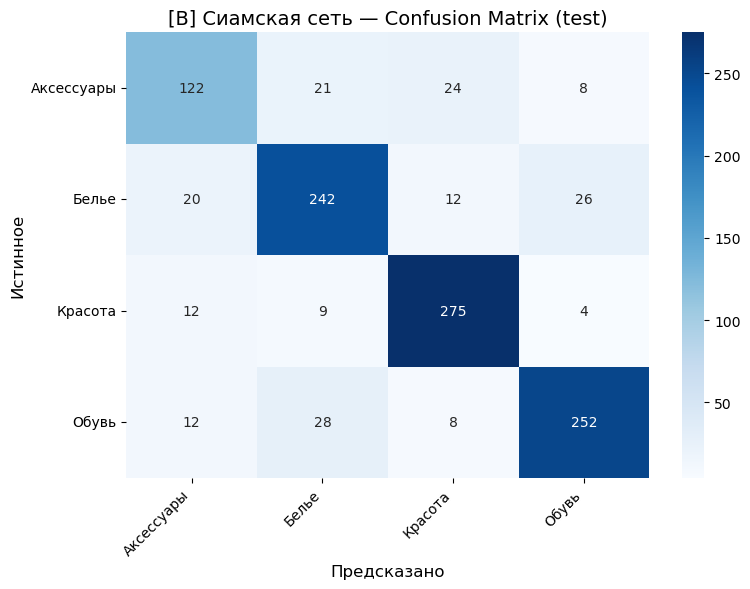

In [25]:
plot_confusion_matrix(y_test_enc, siam_test_pred, CLASS_NAMES,
                      title="[В] Сиамская сеть — Confusion Matrix (test)")

In [26]:
print("\n[В] 10 случайных примеров предсказаний (тест):")
show_random_predictions(y_test, siam_test_pred, le, texts_test, n=10)


[В] 10 случайных примеров предсказаний (тест):
#   Текст отзыва                                  Истинная кат.                Предсказание                 ✓?
---------------------------------------------------------------------------------------------------------------
1   Спинка у бюстгальтера  понравилась и на этом… Белье                        Белье                        yes
2   Кожа. Смотрится симпатично. После кроксов ре… Обувь                        Белье                        no
3   Шарф , не снуд , вискоза , приятный на ощупь… Аксессуары                   Красота                      no
4   Как и писали ниже, ее нужно смывать) иначе л… Красота                      Красота                      yes
5   Хорошие сандали, цвет соответствует фото, не… Обувь                        Белье                        no
6   Отвратительно, приехал, назвал фамилию, выне… Белье                        Красота                      no
7   На мой 48 размер (ОГ - 102, обхват под грудь… Белье      

### Диалоговое окно — Метод В

In [27]:
dialog_log_siam = []

print("=" * 60)
print("[В] Диалог: классификация текста (Сиамская сеть)")
print("Введите 'стоп' для выхода.")
print(f"Доступные категории: {CLASS_NAMES}")
print("=" * 60)

siamese.eval()
cat_t = torch.tensor(cat_emb_matrix, dtype=torch.float32).to(DEVICE)

while True:
    user_input = input("Текст отзыва: ").strip()
    if user_input.lower() in ('стоп', 'stop', 'quit', 'exit', ''):
        break
    emb = model_st.encode([user_input]).astype(np.float32)
    x_t = torch.tensor(emb, dtype=torch.float32).to(DEVICE)
    x_rep = x_t.expand(len(CLASS_NAMES), -1)
    with torch.no_grad():
        scores = torch.sigmoid(siamese(x_rep, cat_t)).cpu().numpy()
    pred_enc = int(np.argmax(scores))
    pred_lbl = CLASS_NAMES[pred_enc]
    conf = float(scores[pred_enc])
    print(f"  → Категория: {pred_lbl}  (score: {conf:.4f})\n")
    dialog_log_siam.append({'text': user_input, 'predicted': pred_lbl, 'score': conf})

if dialog_log_siam:
    with h5py.File('dialog_siamese_rubert.h5', 'w') as f:
        dt = h5py.string_dtype(encoding='utf-8')
        f.create_dataset('texts',       data=np.array([d['text']      for d in dialog_log_siam], dtype='U'), dtype=dt)
        f.create_dataset('predictions', data=np.array([d['predicted'] for d in dialog_log_siam], dtype='U'), dtype=dt)
        f.create_dataset('scores',      data=np.array([d['score']     for d in dialog_log_siam]))
    print(f"Диалог сохранён: dialog_siamese_rubert.h5  ({len(dialog_log_siam)} запросов)")

[В] Диалог: классификация текста (Сиамская сеть)
Введите 'стоп' для выхода.
Доступные категории: ['Аксессуары', 'Белье', 'Красота', 'Обувь']


Текст отзыва:  exit


---
## Итоговое сравнение методов

                     Метод   F1 val  F1 test
А: Логистическая регрессия 0.866150 0.863058
          В: Сиамская сеть 0.852218 0.827954
              Б: Центроиды 0.677358 0.675971


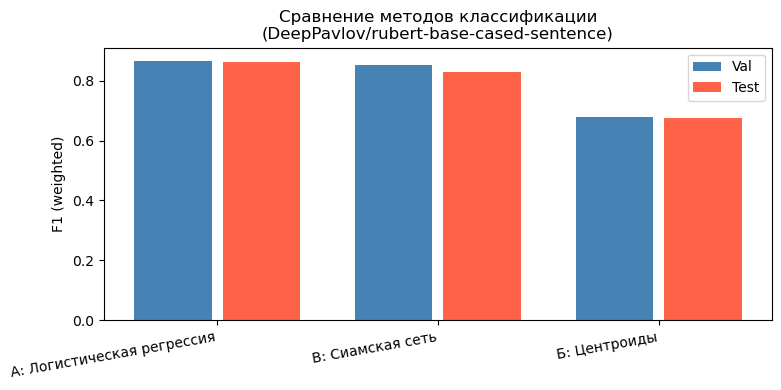

In [28]:
results = pd.DataFrame({
    'Метод':   ['А: Логистическая регрессия', 'Б: Центроиды', 'В: Сиамская сеть'],
    'F1 val':  [lr_f1_val,   cent_f1_val,  siam_f1_val],
    'F1 test': [lr_f1_test,  cent_f1_test, siam_f1_test],
})
results = results.sort_values('F1 test', ascending=False).reset_index(drop=True)
print(results.to_string(index=False))

fig, ax = plt.subplots(figsize=(8, 4))
x = np.arange(len(results))
ax.bar(x - 0.2, results['F1 val'],  0.35, label='Val',  color='steelblue')
ax.bar(x + 0.2, results['F1 test'], 0.35, label='Test', color='tomato')
ax.set_xticks(x)
ax.set_xticklabels(results['Метод'], rotation=10, ha='right')
ax.set_ylabel('F1 (weighted)')
ax.set_title('Сравнение методов классификации\n(DeepPavlov/rubert-base-cased-sentence)')
ax.legend()
plt.tight_layout()
plt.show()